In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/survey_results_public.csv')
print(f"Starting shape: {df.shape}")

Starting shape: (89184, 84)


In [83]:
# The only columns we care about
columns_we_need = [
    'Country',
    'EdLevel',
    'YearsCodePro',
    'Employment',
    'DevType',
    'OrgSize',
    'ConvertedCompYearly'
]

df = df[columns_we_need]
print(f"Shape after column selection: {df.shape}")
df.head()

Shape after column selection: (89184, 7)


,Country,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",9,"Employed, full-time","Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,285000.0
2,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",23,"Employed, full-time","Developer, back-end","5,000 to 9,999 employees",250000.0
3,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",7,"Employed, full-time","Developer, front-end",100 to 499 employees,156000.0
4,Philippines,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4,"Employed, full-time;Independent contractor, fr...","Developer, full-stack",20 to 99 employees,23456.0


In [84]:
print(f"Rows before dropping missing salary: {len(df)}")

df = df[df['ConvertedCompYearly'].notna()]

print(f"Rows after dropping missing salary: {len(df)}")
print(f"Rows removed: {89184 - len(df)}")

Rows before dropping missing salary: 89184
Rows after dropping missing salary: 48019
Rows removed: 41165


In [85]:
print("Before outlier removal:")
print(f"    Max: ${df['ConvertedCompYearly'].max():,.0f}")
print(f"    Min: ${df['ConvertedCompYearly'].min():,.0f}")
print(f"    Rows: {len(df)}")

# Keep only salaries between $10,000 and $250,000
df = df[df['ConvertedCompYearly'] >= 10000]
df = df[df['ConvertedCompYearly'] <= 250000]

print("\nAfter outlier removel:")
print(f"    Max: ${df['ConvertedCompYearly'].max():,.0f}")
print(f"    Min: ${df['ConvertedCompYearly'].min():,.0f}")
print(f"    Rows: {len(df)}")

Before outlier removal:
    Max: $74,351,432
    Min: $1
    Rows: 48019

After outlier removel:
    Max: $250,000
    Min: $10,000
    Rows: 43158


In [86]:
def clean_years_experience(value):
    # Handle the special string cases first
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 50
    # For everything else, try to convert to a number
    # If it fails (NaN, weird string), return NaN
    try:
        return float(value)
    except:
        return np.nan
    
df['YearsCodePro'] = df['YearsCodePro'].apply(clean_years_experience)

print("After cleaning YearsCodePro:")
print(df['YearsCodePro'].describe())
print(f"Missing values remaining: {df['YearsCodePro'].isna().sum()}")

After cleaning YearsCodePro:
count    42999.000000
mean        10.958383
std          8.619805
min          0.500000
25%          5.000000
50%          9.000000
75%         15.000000
max         50.000000
Name: YearsCodePro, dtype: float64
Missing values remaining: 159


In [87]:
# For YearsCodePro — fill missing with the MEDIAN
# Why median and not mean? Because median is less affected by outliers
median_experience = df['YearsCodePro'].median()
df['YearsCodePro'] = df['YearsCodePro'].fillna(median_experience)
print(f"Filled YearsCodePro NaN with median: {median_experience} years")

# For categorical columns — fill missing with 'Unknown'
# We don't want to guess what category they belong to
for col in ['Country', 'EdLevel', 'Employment', 'DevType', 'OrgSize']:
    missing_count = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"Filled {missing_count} missing values in '{col}' with 'Unknown'")

Filled YearsCodePro NaN with median: 9.0 years
Filled 0 missing values in 'Country' with 'Unknown'
Filled 0 missing values in 'EdLevel' with 'Unknown'
Filled 11 missing values in 'Employment' with 'Unknown'
Filled 90 missing values in 'DevType' with 'Unknown'
Filled 32 missing values in 'OrgSize' with 'Unknown'


              FINAL CLEANED DATASET               

Shape: (43158, 7)
Missing values remaining:


Country                0
EdLevel                0
YearsCodePro           0
Employment             0
DevType                0
OrgSize                0
ConvertedCompYearly    0
dtype: int64

Salary range: $10,000 → $250,000
Median salary: $77,104


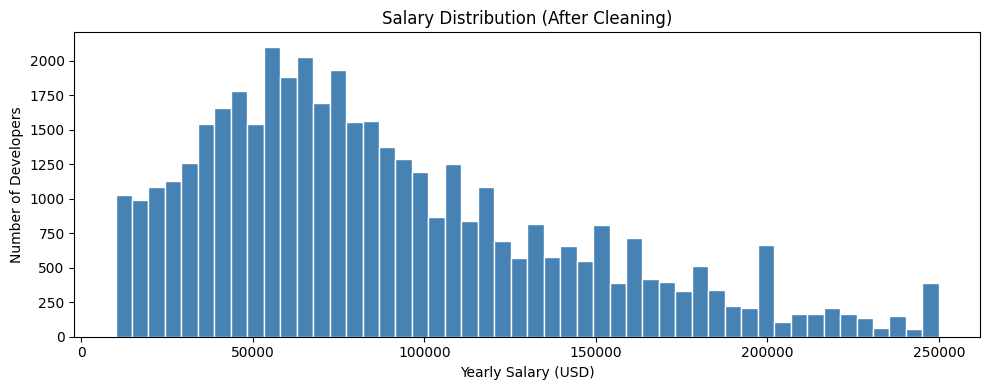

In [88]:
print("=" * 50)
print("FINAL CLEANED DATASET".center(50))
print("=" * 50)
print(f"\nShape: {df.shape}")
print("Missing values remaining:")
print(df.isna().sum())
print(f"\nSalary range: ${df['ConvertedCompYearly'].min():,.0f} → ${df['ConvertedCompYearly'].max():,.0f}")
print(f"Median salary: ${df['ConvertedCompYearly'].median():,.0f}")

# Quick visulazation of the CLEAN salary distribution
plt.figure(figsize=(10, 4))
plt.hist(df['ConvertedCompYearly'], bins=50, color='steelblue', edgecolor='white')
plt.title('Salary Distribution (After Cleaning)')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Developers')
plt.tight_layout()
plt.show()

In [89]:
df.to_csv('../data/processed/survey_clean.csv', index=False)
print("Clean data saved to data/processed/survey_clean.csv")
print(f"Final shape: {df.shape}")

Clean data saved to data/processed/survey_clean.csv
Final shape: (43158, 7)
